# Đồ án: dự đoán doanh số mỗi cặp cửa hàng - sản phẩm

### Bài nộp của Nhóm 6

### Tiếp cận 1: Mỗi cặp (cửa hàng, sản phẩm) --> 1 mô hình dự đoán
Bước 1: Pick ra 1 cặp (cửa hàng, sản phẩm)

Bước 2: Vẽ biểu đồ doanh số 3 tuần đầu của (cửa hàng, sản phẩm)

Bước 3: Dự đoán doanh số tuần 4 của (cửa hàng, sản phẩm)

Bước 5: Sai số dự đoán là bao nhiêu

Bước 6: Lặp lại tương tự cho tất cả các cặp (cửa hàng, sản phẩm) --> tính sai số trung bình



---

Trước tiên, ta cần load dữ liệu `transactions-2025-12.parquet`.

In [563]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

trans_lf = (
    pl.scan_parquet('./transactions-2025-12.parquet')
)

In [564]:
print(trans_lf.limit(5).collect())

shape: (5, 8)
┌─────────────┬────────────┬────────────┬──────────┬────────────┬────────────┬──────────┬──────────┐
│ customer_id ┆ item_id    ┆ price      ┆ channel  ┆ payment    ┆ updated_da ┆ location ┆ quantity │
│ ---         ┆ ---        ┆ ---        ┆ ---      ┆ ---        ┆ te         ┆ ---      ┆ ---      │
│ i32         ┆ str        ┆ decimal[38 ┆ str      ┆ str        ┆ ---        ┆ i32      ┆ i32      │
│             ┆            ┆ ,4]        ┆          ┆            ┆ datetime[μ ┆          ┆          │
│             ┆            ┆            ┆          ┆            ┆ s]         ┆          ┆          │
╞═════════════╪════════════╪════════════╪══════════╪════════════╪════════════╪══════════╪══════════╡
│ 8861340     ┆ 0151000000 ┆ 1625000.00 ┆ In-Store ┆ Tiền mặt   ┆ 2025-12-12 ┆ 385      ┆ 1        │
│             ┆ 003        ┆ 00         ┆          ┆            ┆ 16:44:47.7 ┆          ┆          │
│             ┆            ┆            ┆          ┆            ┆ 93         

Để thực hiện các bước tiếp cận, ta cần một chút xử lý dữ liệu

Đầu tiên, ta sẽ tạo thêm cột `week` để biết giao dịch được thực hiện ở tuần thứ mấy. Tiếp đó, ta sẽ agg để đếm tổng số lượng theo từng cặp `(location, item_id)` với mỗi tuần.

In [565]:
weekly_trans = (
    trans_lf
    .with_columns(
        pl.col("updated_date").dt.truncate("1w").alias("fst_day_of_week")
    )
    .with_columns(
        pl.when(pl.col("fst_day_of_week").dt.day() <= 7).then(1)
        .when(pl.col("fst_day_of_week").dt.day() <= 14).then(2)
        .when(pl.col("fst_day_of_week").dt.day() <= 21).then(3)
        .otherwise(4)
        .alias("week")
    )
    .group_by(["location", "item_id"])
    .agg([
        pl.when(pl.col("week") == 1).then(pl.col("quantity")).otherwise(0).sum().alias("w1"),
        pl.when(pl.col("week") == 2).then(pl.col("quantity")).otherwise(0).sum().alias("w2"),
        pl.when(pl.col("week") == 3).then(pl.col("quantity")).otherwise(0).sum().alias("w3"),
        pl.when(pl.col("week") == 4).then(pl.col("quantity")).otherwise(0).sum().alias("w4"),
    ])
    .collect()
)

In [566]:
weekly_trans.limit(5)

location,item_id,w1,w2,w3,w4
i32,str,i32,i32,i32,i32
912,"""0054000000006""",0,0,0,1
255,"""5918000000007""",1,1,6,2
367,"""1512000000004""",6,7,4,6
721,"""3953000000991""",0,0,0,1
536,"""2453000000002""",0,0,1,1


Ta tạo một hàm để vẽ số lượng bán được trong 3 tuần đầu theo từng (cửa hàng, sản phẩm)

In [568]:
def plot_sales(location, item_id):
    selected_pair = weekly_trans.filter(
        (pl.col('location') == location) & (pl.col('item_id') == item_id)
    )

    week1 = selected_pair['w1']
    week2 = selected_pair['w2']
    week3 = selected_pair['w3']
    
    weeks = np.array([1, 2, 3])
    quantities = np.array([week1, week2, week3])

    plt.figure(figsize=(8, 5))
    
    plt.scatter(weeks[:3], quantities[:3], color='blue')
    
    plt.xlabel('Week')
    plt.ylabel('Quantity Sold')
    plt.xticks(weeks, ['Week 1', 'Week 2', 'Week 3'])
    plt.legend()
    plt.show()


Ta lấy ví dụ là `location=119`, và `item_id = "2489000000002"`

/tmp/ipykernel_1075958/300242512.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


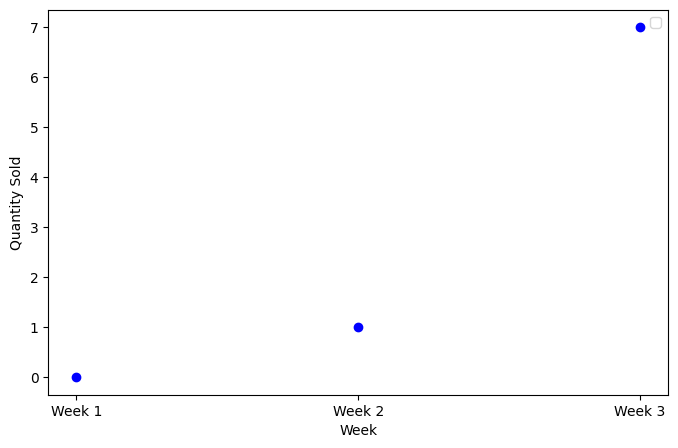

In [570]:
plot_sales(119, "2489000000002")

Ở đây, để dự đoán tuần thứ 4 theo từng cửa hàng theo từng sản phẩm, ta sử dụng hồi quy tuyến tính để dự đoán đường thẳng.

In [571]:
def predict_week4(row):
    week1 = row['w1']
    week2 = row['w2']
    week3 = row['w3']
    
    x = np.array([1, 2, 3])
    y = np.array([week1, week2, week3])
    a, b = np.polyfit(x, y, 1)
    
    return max(0, int(np.ceil(a * 4 + b)))

result = (
    weekly_trans.with_columns(
        pl.struct(['w1', 'w2', 'w3']).map_elements(predict_week4).alias('predicted_week4')
    )
    .with_columns(
        (np.abs(pl.col('w4') - pl.col('predicted_week4'))).alias('error')
    )
    
)

table_result = result.select(['location', 'item_id', 'predicted_week4', 'w4', 'error']).rename({'w4': 'actual_week4'})


Ta sẽ tính sai số trung bình cho toàn bộ cặp dữ liệu

In [572]:
# Tính sai số trung bình (MAE)
mean_error = table_result.select(pl.col('error').abs().mean()).item()

print(table_result)
print(f"Sai số trung bình (MAE): {mean_error:.4f}")

shape: (1_167_571, 5)
┌──────────┬───────────────┬─────────────────┬──────────────┬───────┐
│ location ┆ item_id       ┆ predicted_week4 ┆ actual_week4 ┆ error │
│ ---      ┆ ---           ┆ ---             ┆ ---          ┆ ---   │
│ i32      ┆ str           ┆ i64             ┆ i32          ┆ i64   │
╞══════════╪═══════════════╪═════════════════╪══════════════╪═══════╡
│ 912      ┆ 0054000000006 ┆ 0               ┆ 1            ┆ 1     │
│ 255      ┆ 5918000000007 ┆ 8               ┆ 2            ┆ 6     │
│ 367      ┆ 1512000000004 ┆ 4               ┆ 6            ┆ 2     │
│ 721      ┆ 3953000000991 ┆ 0               ┆ 1            ┆ 1     │
│ 536      ┆ 2453000000002 ┆ 2               ┆ 1            ┆ 1     │
│ …        ┆ …             ┆ …               ┆ …            ┆ …     │
│ 615      ┆ 7375000000001 ┆ 3               ┆ 0            ┆ 3     │
│ 1008     ┆ 1308000000002 ┆ 2               ┆ 0            ┆ 2     │
│ 708      ┆ 0006040000181 ┆ 3               ┆ 1            ┆ 2     

Để trực quan, ta sẽ vẽ biểu đồ của 4 tuần.

In [574]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sales_with_trend(location, item_id):
    # Chọn cặp (cửa hàng, sản phẩm)
    selected_pair = result.filter(
        (pl.col('location') == location) & (pl.col('item_id') == item_id)
    )

    # Lấy doanh số 3 tuần đầu và tuần 4 thực tế
    week1 = selected_pair['w1']
    week2 = selected_pair['w2']
    week3 = selected_pair['w3']
    week4_actual = selected_pair['w4']  # Tuần 4 thực tế

    # Fit đường thẳng qua tuần 1, 2, 3
    x = np.array([1, 2, 3])
    y = np.array([week1, week2, week3])
    a, b = np.polyfit(x, y, 1)

    # Vẽ điểm và đường thẳng
    weeks = np.array([1, 2, 3, 4])
    quantities = np.array([week1, week2, week3, week4_actual])

    plt.figure(figsize=(8, 5))
    
    plt.scatter(weeks[:3], quantities[:3], color='blue', label='Weeks 1-3 (Actual)')
    # Vẽ tuần 4 thực tế
    plt.scatter(4, week4_actual, color='green', label='Week 4 (Actual)')
    
    # Vẽ đường thẳng nội suy từ tuần 1 đến 4
    trend_line_x = np.array([1, 2, 3, 4])
    trend_line_y = a * trend_line_x + b
    plt.plot(trend_line_x, trend_line_y, color='red', linestyle='--', label='Trend Line (Weeks 1-3)')

    plt.xlabel('Week')
    plt.ylabel('Quantity Sold')
    plt.xticks(weeks, ['Week 1', 'Week 2', 'Week 3', 'Week 4'])
    plt.legend()
    plt.show()


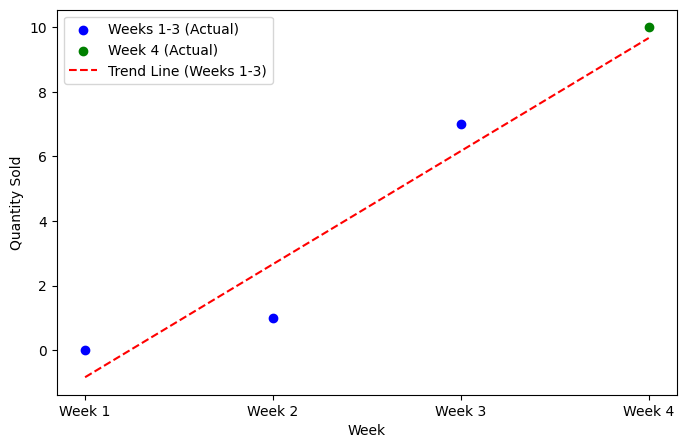

In [575]:
plot_sales_with_trend(119, "2489000000002")

### Tiếp cập 2 Ở đây cách tiếp cận của em là sử dụng mô hình Ridge Regression.
Tập train của mô hình là 3 tuần đầu. Còn tập test sẽ là 3 tuần cuối cho mỗi cửa hàng và sản phẩm.

In [576]:
X_train = weekly_trans.select(["w1","w2"]).to_numpy()
y_train = weekly_trans["w3"].to_numpy()

X_test = weekly_trans.select(["w2","w3"]).to_numpy()
y_test = weekly_trans["w4"].to_numpy()

In [577]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)

model.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [578]:
pred = model.predict(X_test)

In [579]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)

print("MAE:", mae)

MAE: 1.4107659940713557


In [580]:
def plot_sales_with_ridge(location, item_id):
    selected_pair = weekly_trans.filter(
        (pl.col("location") == location) &
        (pl.col("item_id") == item_id)
    )

    if selected_pair.height == 0:
        print("Item not found")
        return

    week1 = selected_pair["w1"][0]
    week2 = selected_pair["w2"][0]
    week3 = selected_pair["w3"][0]
    week4_actual = selected_pair["w4"][0]

    X = np.array([[week2, week3]])
    week4_pred = model.predict(X)[0]

    plt.figure(figsize=(8,5))

    plt.scatter([1,2,3], [week1, week2, week3], label="Weeks 1-3 Actual")

    plt.scatter(4, week4_actual, label="Week 4 Actual")

    plt.scatter(4, week4_pred, marker="x", s=120, label="Week 4 Predicted")

    plt.xticks([1,2,3,4], ["Week 1","Week 2","Week 3","Week 4"])
    plt.xlabel("Week")
    plt.ylabel("Quantity Sold")
    plt.legend()

    plt.show()

    print("Week4 Actual:", week4_actual)
    print("Week4 Predicted:", week4_pred)

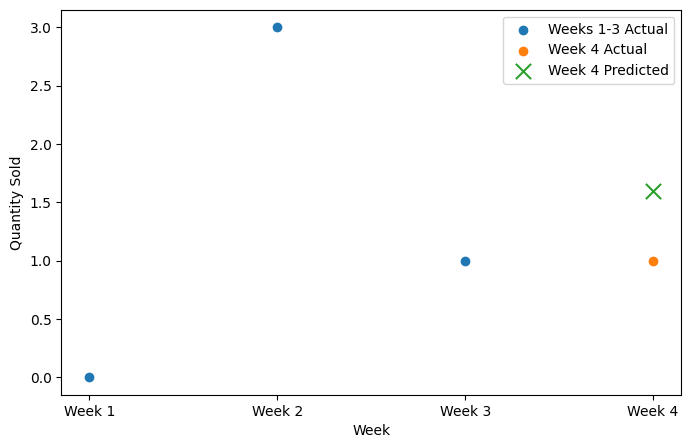

Week4 Actual: 1
Week4 Predicted: 1.5967765044993065


In [581]:
plot_sales_with_ridge(407, "2202000000002")